# 01 — Exploratory Data Analysis (EDA)
**Resume Classification — Deep Learning Project**

Notebook ini bertujuan untuk memahami struktur, distribusi, dan karakteristik dataset resume sebelum masuk ke tahap preprocessing dan modeling.

---
**Input :** `data/df_dataset_Resume_cleaned.csv`  
**Output :** insight & catatan untuk notebook berikutnya (`02_preprocessing.ipynb`)

## 1. Setup & Import Library

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
from collections import Counter

# Supaya grafik rapi
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['font.size'] = 12
sns.set_style('whitegrid')

# Supaya semua kolom tampil
pd.set_option('display.max_colwidth', 120)

print('Library berhasil di-import!')

Library berhasil di-import!


## 2. Load Dataset

In [2]:
# Sesuaikan path jika berbeda
DATA_PATH = '../data/raw/df_dataset_Resume_cleaned.csv'

df = pd.read_csv(DATA_PATH)
print(f'Dataset berhasil dimuat!')
print(f'Jumlah baris : {df.shape[0]:,}')
print(f'Jumlah kolom : {df.shape[1]}')
df.head(3)

Dataset berhasil dimuat!
Jumlah baris : 6,844
Jumlah kolom : 3


,category,job_title,Text
0,Java Developers/Architects Resumes,Java Developer,Flair for technology and willing to take challenging assignments with over 6 years of versatile experience in analys...
1,Java Developers/Architects Resumes,Sr. Java/J2EE Developer,Senior Java Developer with around 7+ years of JAVA/J2EE Enterprise Application Development experience in Client/Serv...
2,Java Developers/Architects Resumes,Sr. iOS Developer,"Overall 7 years of experience in design and development of User Interface applications, integrating with numerous da..."


## 3. Informasi Dasar Dataset

In [3]:
print('=== Tipe Data ===')
print(df.dtypes)
print()
print('=== Missing Values ===')
print(df.isnull().sum())
print()
print('=== Duplikat pada kolom Text ===')
n_dup = df['Text'].duplicated().sum()
print(f'{n_dup} baris duplikat ditemukan ({n_dup/len(df)*100:.1f}% dari total data)')

=== Tipe Data ===
category     object
job_title    object
Text         object
dtype: object

=== Missing Values ===
category     0
job_title    0
Text         0
dtype: int64

=== Duplikat pada kolom Text ===
1103 baris duplikat ditemukan (16.1% dari total data)


> **Catatan:** Duplikat teks perlu diperhatikan. Bisa dihapus di tahap preprocessing agar model tidak belajar dari data yang sama berulang kali.

In [4]:
print('=== Jumlah Nilai Unik per Kolom ===')
for col in df.columns:
    print(f'  {col:12s}: {df[col].nunique():,} nilai unik')

=== Jumlah Nilai Unik per Kolom ===
  category    : 9 nilai unik
  job_title   : 3,691 nilai unik
  Text        : 5,741 nilai unik


## 4. Distribusi Label (Category)

In [5]:
category_counts = df['category'].value_counts()
print('Distribusi kategori:')
print(category_counts)
print(f'\nTotal kategori: {len(category_counts)}')

Distribusi kategori:
category
Datawarehousing, ETL, Informatica Resumes         894
SQL Developers Resumes                            795
Network and Systems Administrators Resumes        779
Business Intelligence, Business Object Resumes    769
Project Manager Resumes                           757
Business Analyst (BA) Resumes                     751
Web Developer Resumes                             731
Recruiter Resumes                                 728
Java Developers/Architects Resumes                640
Name: count, dtype: int64

Total kategori: 9


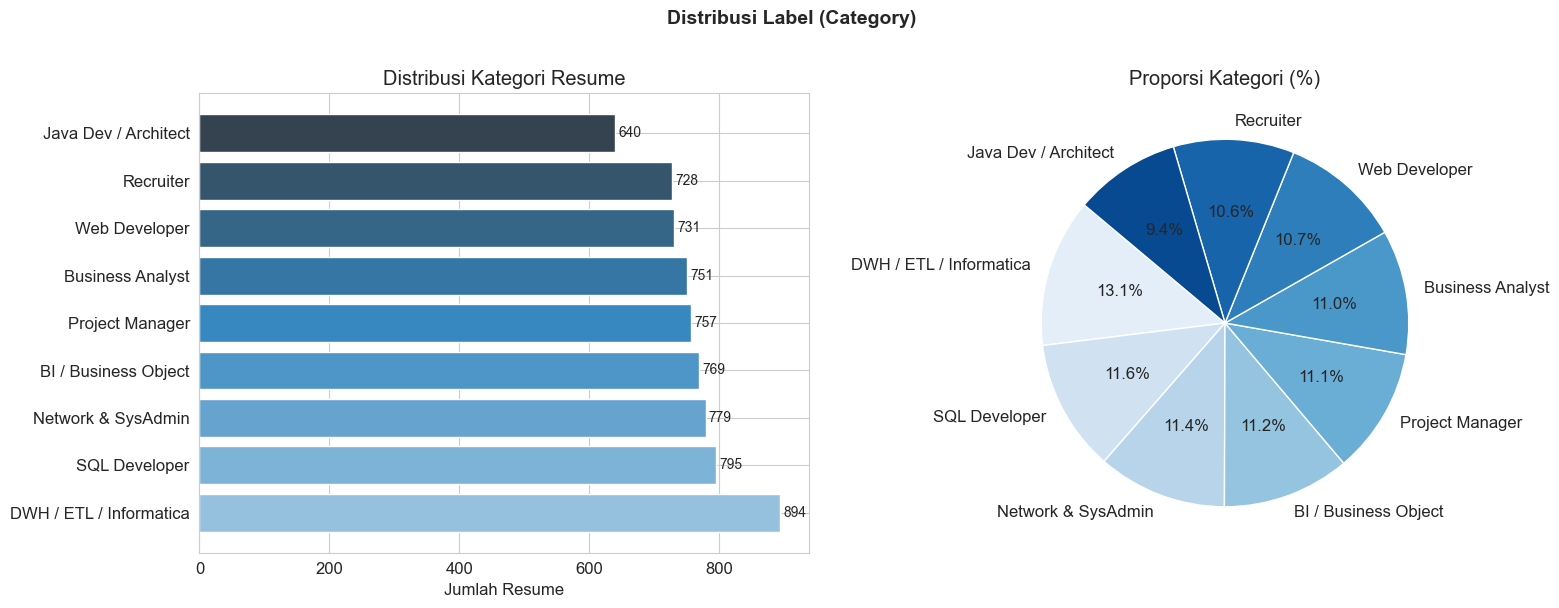

Grafik disimpan ke data/eda_category_distribution.png


In [6]:
# Buat label pendek agar grafik tidak terpotong
short_labels = {
    'Datawarehousing, ETL, Informatica Resumes'        : 'DWH / ETL / Informatica',
    'SQL Developers Resumes'                           : 'SQL Developer',
    'Network and Systems Administrators Resumes'        : 'Network & SysAdmin',
    'Business Intelligence, Business Object Resumes'   : 'BI / Business Object',
    'Project Manager Resumes'                          : 'Project Manager',
    'Business Analyst (BA) Resumes'                    : 'Business Analyst',
    'Web Developer Resumes'                            : 'Web Developer',
    'Recruiter Resumes'                                : 'Recruiter',
    'Java Developers/Architects Resumes'               : 'Java Dev / Architect',
}

df['category_short'] = df['category'].map(short_labels)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Bar chart
counts = df['category_short'].value_counts()
colors = sns.color_palette('Blues_d', len(counts))
axes[0].barh(counts.index, counts.values, color=colors)
axes[0].set_xlabel('Jumlah Resume')
axes[0].set_title('Distribusi Kategori Resume')
for i, v in enumerate(counts.values):
    axes[0].text(v + 5, i, str(v), va='center', fontsize=10)

# Pie chart
axes[1].pie(counts.values, labels=counts.index, autopct='%1.1f%%',
            colors=sns.color_palette('Blues', len(counts)), startangle=140)
axes[1].set_title('Proporsi Kategori (%)')

plt.suptitle('Distribusi Label (Category)', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('../data/eda_category_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print('Grafik disimpan ke data/eda_category_distribution.png')

> **Insight:** Distribusi antar kategori relatif seimbang (640–894 per kelas). Tidak ada class imbalance yang ekstrem, sehingga tidak wajib melakukan oversampling/undersampling.

## 5. Analisis Panjang Teks

In [7]:
df['text_len']   = df['Text'].str.len()
df['word_count'] = df['Text'].str.split().str.len()

print('=== Statistik Panjang Karakter ===')
print(df['text_len'].describe().round(0))
print()
print('=== Statistik Jumlah Kata ===')
print(df['word_count'].describe().round(0))

=== Statistik Panjang Karakter ===
count     6844.0
mean     11433.0
std       6035.0
min        595.0
25%       7193.0
50%      10769.0
75%      14740.0
max      61052.0
Name: text_len, dtype: float64

=== Statistik Jumlah Kata ===
count    6844.0
mean     1577.0
std       844.0
min        76.0
25%       990.0
50%      1480.0
75%      2030.0
max      8341.0
Name: word_count, dtype: float64


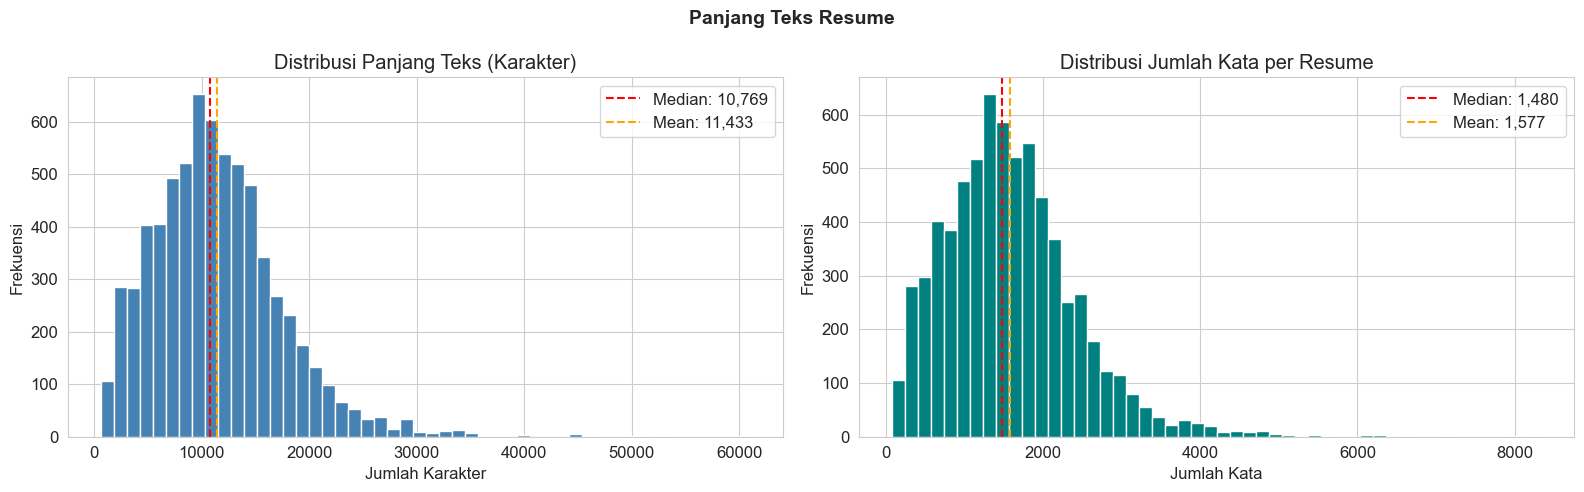

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Distribusi panjang karakter
axes[0].hist(df['text_len'], bins=50, color='steelblue', edgecolor='white')
axes[0].axvline(df['text_len'].median(), color='red', linestyle='--', label=f'Median: {df["text_len"].median():,.0f}')
axes[0].axvline(df['text_len'].mean(), color='orange', linestyle='--', label=f'Mean: {df["text_len"].mean():,.0f}')
axes[0].set_xlabel('Jumlah Karakter')
axes[0].set_ylabel('Frekuensi')
axes[0].set_title('Distribusi Panjang Teks (Karakter)')
axes[0].legend()

# Distribusi jumlah kata
axes[1].hist(df['word_count'], bins=50, color='teal', edgecolor='white')
axes[1].axvline(df['word_count'].median(), color='red', linestyle='--', label=f'Median: {df["word_count"].median():,.0f}')
axes[1].axvline(df['word_count'].mean(), color='orange', linestyle='--', label=f'Mean: {df["word_count"].mean():,.0f}')
axes[1].set_xlabel('Jumlah Kata')
axes[1].set_ylabel('Frekuensi')
axes[1].set_title('Distribusi Jumlah Kata per Resume')
axes[1].legend()

plt.suptitle('Panjang Teks Resume', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../data/eda_text_length.png', dpi=150, bbox_inches='tight')
plt.show()

C:\Users\ASUS\AppData\Local\Temp\ipykernel_388\112974799.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='category_short', y='word_count', order=cat_order, palette='Blues', ax=ax)
C:\Users\ASUS\AppData\Local\Temp\ipykernel_388\112974799.py:6: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha='right')


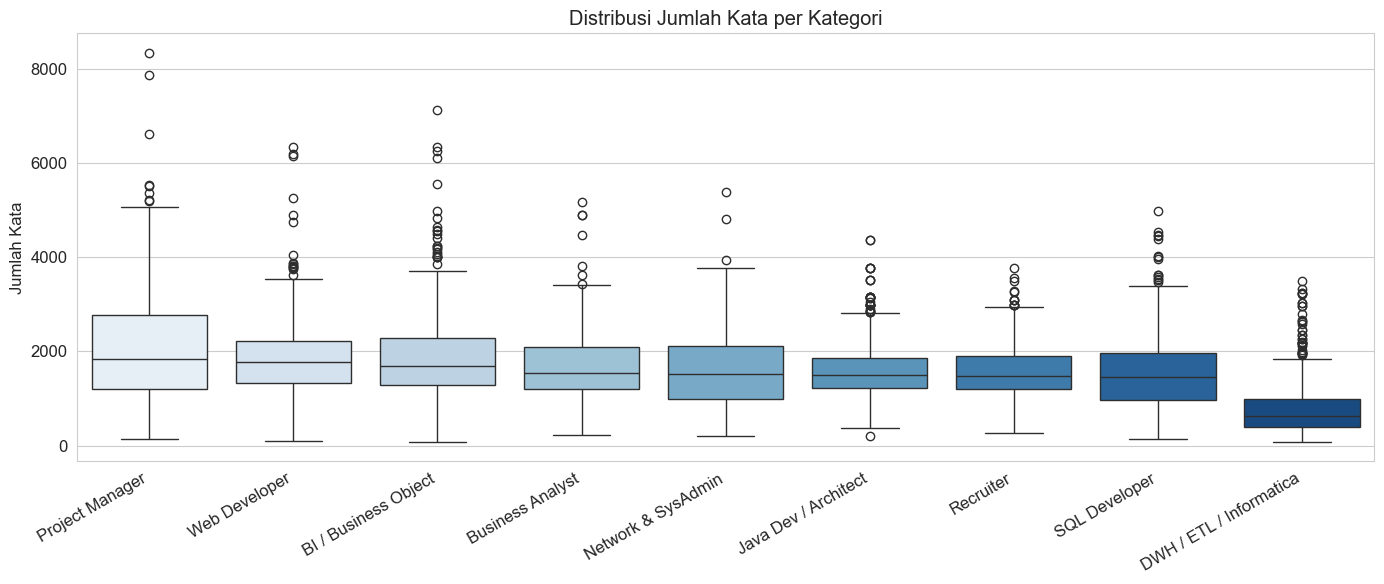


Rata-rata jumlah kata per kategori:
category_short
Project Manager            2047.0
BI / Business Object       1815.0
Web Developer              1815.0
Business Analyst           1645.0
Java Dev / Architect       1594.0
Network & SysAdmin         1581.0
Recruiter                  1560.0
SQL Developer              1541.0
DWH / ETL / Informatica     755.0
Name: word_count, dtype: float64


In [9]:
# Panjang teks per kategori
fig, ax = plt.subplots(figsize=(14, 6))

cat_order = df.groupby('category_short')['word_count'].median().sort_values(ascending=False).index
sns.boxplot(data=df, x='category_short', y='word_count', order=cat_order, palette='Blues', ax=ax)
ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha='right')
ax.set_xlabel('')
ax.set_ylabel('Jumlah Kata')
ax.set_title('Distribusi Jumlah Kata per Kategori')

plt.tight_layout()
plt.savefig('../data/eda_wordcount_per_category.png', dpi=150, bbox_inches='tight')
plt.show()

print('\nRata-rata jumlah kata per kategori:')
print(df.groupby('category_short')['word_count'].mean().round(0).sort_values(ascending=False))

> **Insight penting untuk modeling:**
> - Rata-rata resume punya **~1.577 kata** (~11.000 karakter).
> - BERT standard hanya support **512 token** → banyak teks akan terpotong.
> - Pertimbangkan **Longformer** (support 4096 token) agar informasi tidak banyak hilang.
> - Kategori **Project Manager** memiliki teks paling panjang (~2047 kata rata-rata).
> - Kategori **DWH/ETL/Informatica** memiliki teks paling pendek (~755 kata).

## 6. Analisis Job Title

In [10]:
print(f'Total job title unik: {df["job_title"].nunique():,}')
print()
print('15 job title paling sering muncul:')
print(df['job_title'].value_counts().head(15))

Total job title unik: 3,691

15 job title paling sering muncul:
job_title
Business Analyst             155
Informatica Developer         99
Java Developer                99
QA Analyst                    74
IOS Developer                 72
Sr. Informatica Developer     66
UI Developer                  66
Sr. Business Analyst          64
Java/J2EE Developer           46
Project Manager               39
Software Developer            37
Sr. Java Developer            35
Network Engineer              34
Web Developer                 34
Oracle DBA                    33
Name: count, dtype: int64


C:\Users\ASUS\AppData\Local\Temp\ipykernel_388\3404767546.py:6: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(jt_per_cat.index, rotation=30, ha='right')


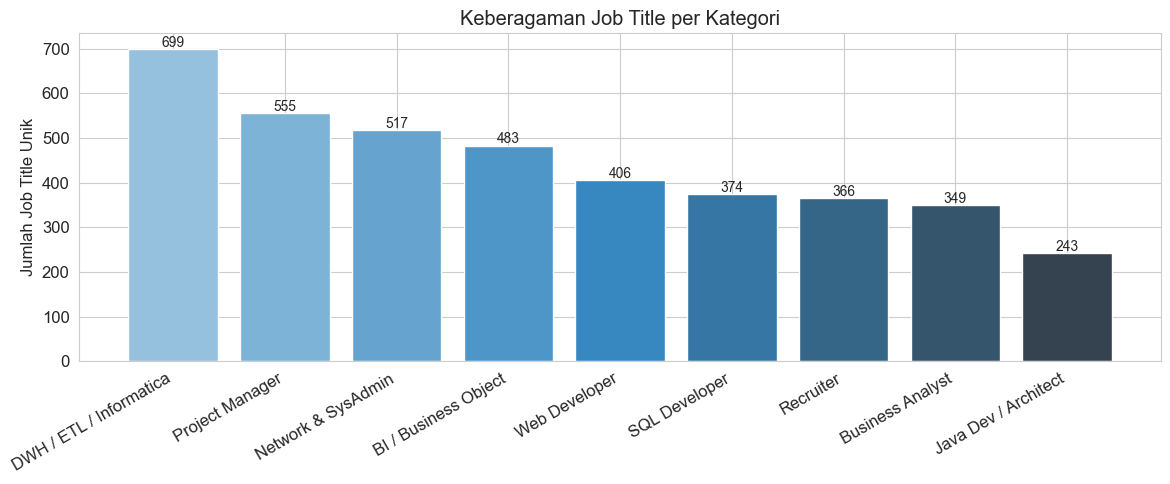

In [11]:
# Jumlah job title unik per kategori
jt_per_cat = df.groupby('category_short')['job_title'].nunique().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(12, 5))
bars = ax.bar(jt_per_cat.index, jt_per_cat.values, color=sns.color_palette('Blues_d', len(jt_per_cat)))
ax.set_xticklabels(jt_per_cat.index, rotation=30, ha='right')
ax.set_ylabel('Jumlah Job Title Unik')
ax.set_title('Keberagaman Job Title per Kategori')
for bar, val in zip(bars, jt_per_cat.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5, str(val), ha='center', fontsize=10)

plt.tight_layout()
plt.savefig('../data/eda_jobtitle_diversity.png', dpi=150, bbox_inches='tight')
plt.show()

> **Insight:** Kolom `job_title` memiliki **3.691 nilai unik** — terlalu banyak untuk dijadikan target klasifikasi langsung. Fokus modeling ke kolom `category` (9 kelas) yang jauh lebih manageable.

## 7. Analisis Kata yang Sering Muncul

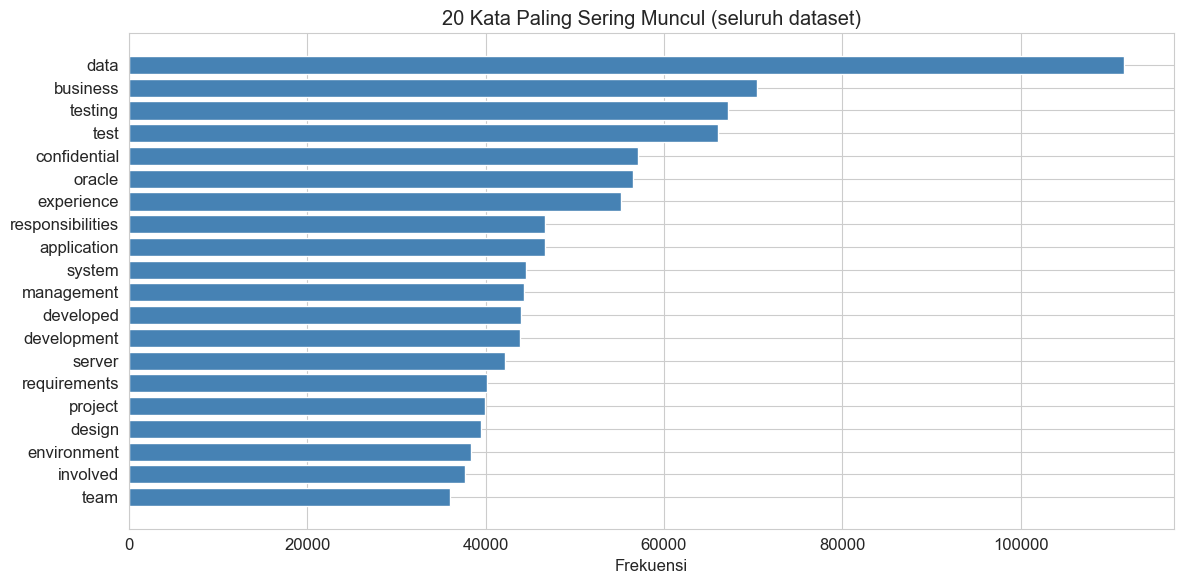

In [12]:
# Stopwords sederhana (bisa diperluas)
STOPWORDS = {
    'with','that','this','have','from','they','will','been','were','their',
    'which','into','more','also','than','other','such','after','about',
    'your','over','when','upon','some','year','years','work','worked',
    'working','responsible','include','including','skills','ability',
    'used','using','used','good','well'
}

def get_top_words(texts, n=20, stopwords=STOPWORDS):
    all_text = ' '.join(texts).lower()
    words = re.findall(r'\b[a-z]{4,}\b', all_text)
    words = [w for w in words if w not in stopwords]
    return Counter(words).most_common(n)

top_words_global = get_top_words(df['Text'])
words_df = pd.DataFrame(top_words_global, columns=['word', 'count'])

fig, ax = plt.subplots(figsize=(12, 6))
ax.barh(words_df['word'][::-1], words_df['count'][::-1], color='steelblue')
ax.set_xlabel('Frekuensi')
ax.set_title('20 Kata Paling Sering Muncul (seluruh dataset)')
plt.tight_layout()
plt.savefig('../data/eda_top_words_global.png', dpi=150, bbox_inches='tight')
plt.show()

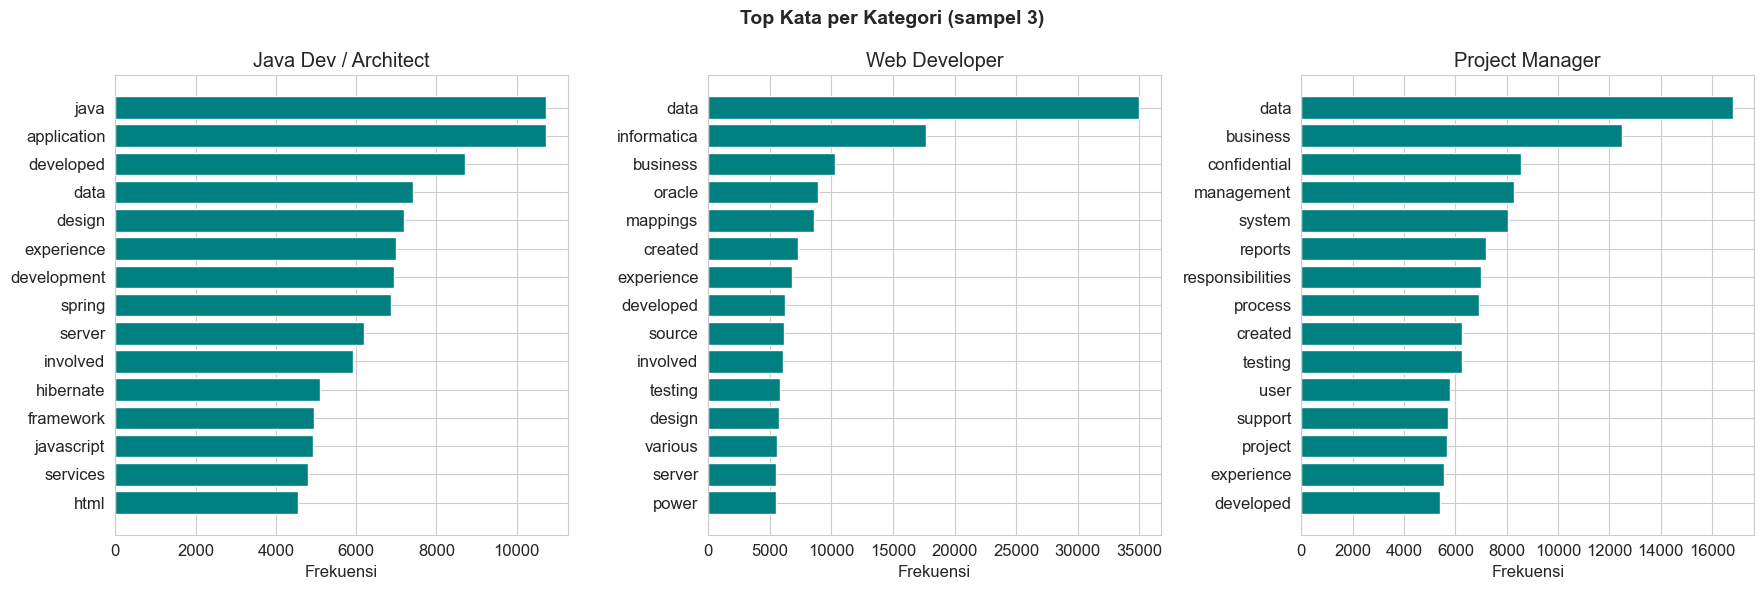

In [13]:
# Top kata per kategori (sampel 3 kategori)
sample_categories = [
    'Java Developer / Architect',
    'Web Developer',
    'Project Manager'
]

# Mapping balik ke nama asli
reverse_map = {v: k for k, v in short_labels.items()}

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

sample_cats_short = ['Java Dev / Architect', 'Web Developer', 'Project Manager']

for ax, cat_short in zip(axes, sample_cats_short):
    cat_full = reverse_map[cat_short]
    texts = df[df['category'] == cat_full]['Text'].tolist()
    top = get_top_words(texts, n=15)
    words_, counts_ = zip(*top)
    ax.barh(list(words_)[::-1], list(counts_)[::-1], color='teal')
    ax.set_title(cat_short)
    ax.set_xlabel('Frekuensi')

plt.suptitle('Top Kata per Kategori (sampel 3)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../data/eda_top_words_per_category.png', dpi=150, bbox_inches='tight')
plt.show()

## 8. Contoh Teks Resume

In [14]:
# Tampilkan 1 sampel per kategori
print('=== CONTOH TEKS RESUME (500 karakter pertama) ===\n')
for cat in df['category'].unique():
    sample = df[df['category'] == cat]['Text'].iloc[0]
    short = short_labels.get(cat, cat)
    print(f'--- [{short}] ---')
    print(sample[:500])
    print()

=== CONTOH TEKS RESUME (500 karakter pertama) ===

--- [Java Dev / Architect] ---
Flair for technology and willing to take challenging assignments with over 6 years of versatile experience in analysis, design, development and implementation of N - tier architecture based applications, Business to Business Applications, Business to Client based applications, distributed components, internet/intranet applications. Areas of expertise include analysis, design and development of applications using JEE/J2EE technologies including JAVA, Servlets, JSP, EJB, JMS, JDBC, JNDI, JTA, Web 

--- [Web Developer] ---
Over 6 Years of working experience as Informatica ETL developer using Informatica power center 9.x/8.x/7.x with strong knowledge on Data ware house concepts and data modelling. Extreme Utilization of Source Analyzer, Transformation Developer, Mapplet Designer, Mapping Designer, Workflow Manager, Workflow Monitor and Repository Manager, metadata Manager. Strong knowledge in Installation, co

## 9. Ringkasan Temuan EDA

In [16]:
print('=' * 60)
print('RINGKASAN TEMUAN EDA')
print('=' * 60)

print(f"""
DATASET
  Total baris       : {len(df):,}
  Kolom             : category, job_title, Text
  Missing values    : tidak ada
  Duplikat teks     : {df['Text'].duplicated().sum():,} baris

LABEL (category)
  Jumlah kelas      : {df['category'].nunique()}
  Distribusi        : relatif seimbang (640–894 per kelas)
  Kesimpulan        : tidak perlu class weighting / oversampling

TEKS
  Rata-rata kata    : {df['word_count'].mean():.0f} kata per resume
  Median kata       : {df['word_count'].median():.0f} kata
  Paling panjang    : {df['word_count'].max():,} kata
  Paling pendek     : {df['word_count'].min()} kata

JOB TITLE
  Nilai unik        : {df['job_title'].nunique():,} → terlalu banyak utk target
  Rekomendasi       : gunakan 'category' sebagai target klasifikasi

REKOMENDASI UNTUK MODELING
  1. Hapus 1.103 duplikat sebelum training
  2. Encode 'category' ke integer (LabelEncoder)
  3. Teks sangat panjang → pakai Longformer (max 4096 token)
     atau BERT dengan strategi truncation
  4. Split: 70% train / 15% val / 15% test
""")
print('=' * 60)

RINGKASAN TEMUAN EDA

DATASET
  Total baris       : 6,844
  Kolom             : category, job_title, Text
  Missing values    : tidak ada
  Duplikat teks     : 1,103 baris

LABEL (category)
  Jumlah kelas      : 9
  Distribusi        : relatif seimbang (640–894 per kelas)
  Kesimpulan        : tidak perlu class weighting / oversampling

TEKS
  Rata-rata kata    : 1577 kata per resume
  Median kata       : 1480 kata
  Paling panjang    : 8,341 kata
  Paling pendek     : 76 kata

JOB TITLE
  Nilai unik        : 3,691 → terlalu banyak utk target
  Rekomendasi       : gunakan 'category' sebagai target klasifikasi

REKOMENDASI UNTUK MODELING
  1. Hapus 1.103 duplikat sebelum training
  2. Encode 'category' ke integer (LabelEncoder)
  3. Teks sangat panjang → pakai Longformer (max 4096 token)
     atau BERT dengan strategi truncation
  4. Split: 70% train / 15% val / 15% test

